In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [26]:
df = pd.read_csv('water_potability_clean.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (3276, 10)


In [27]:
X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_train_lda:    {X_train_lda.shape}")

Shape of X_train_scaled: (2784, 9)
Shape of X_train_lda:    (2784, 1)


In [33]:
# n_components=0.95 znači da želimo da sačuvamo 95% originalne varijanse.
# PCA će sam odlučiti koliko komponenti (obeležja) mu je za to potrebno.
pca = PCA(n_components=0.95)

# Učimo PCA na SKALIRANIM trening podacima i transformišemo ih
X_train_pca = pca.fit_transform(X_train_scaled)

# Primenjujemo naučenu transformaciju i na test podatke
X_test_pca = pca.transform(X_test_scaled)

print("--- Dimensionality Reduction using PCA complete ---")
print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after PCA to preserve 95% variance: {X_train_pca.shape[1]}")

--- Dimensionality Reduction using PCA complete ---
Original number of features: 9
Number of features after PCA to preserve 95% variance: 9


In [34]:
# Definišemo prostor hiperparametara koje želimo da testiramo
# C: Parametar regularizacije.
# gamma: Koeficijent kernela za 'rbf'. 'scale' je dobra podrazumevana vrednost.
# kernel: Koristimo 'rbf' za nelinearne probleme.
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf']
}

# --- 1. GridSearchCV na ORIGINALNIM obeležjima ---
print("--- Hyperparameter Tuning for SVM on Original Features ---")
# probability=True je korisno ako kasnije želimo da znamo verovatnoće predikcija
grid_original = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_original.fit(X_train_scaled, y_train)

print(f"Best parameters for original features: {grid_original.best_params_}")
print(f"Best cross-validation accuracy: {grid_original.best_score_:.4f}")

# --- 2. GridSearchCV na LDA obeležjima ---
print("\n--- Hyperparameter Tuning for SVM on LDA Features ---")
grid_lda = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_lda.fit(X_train_lda, y_train)
print(f"Best parameters for LDA features: {grid_lda.best_params_}")
print(f"Best cross-validation accuracy: {grid_lda.best_score_:.4f}")

# --- 3. GridSearchCV na PCA obeležjima ---
print("\n--- Hyperparameter Tuning for SVM on PCA Features ---")
grid_pca = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_pca.fit(X_train_pca, y_train)

print(f"Best parameters for PCA features: {grid_pca.best_params_}")
print(f"Best cross-validation accuracy: {grid_pca.best_score_:.4f}")



--- Hyperparameter Tuning for SVM on Original Features ---
Best parameters for original features: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.6767

--- Hyperparameter Tuning for SVM on LDA Features ---
Best parameters for LDA features: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.6315

--- Hyperparameter Tuning for SVM on PCA Features ---
Best parameters for PCA features: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.6767


--- Final Evaluation and Conclusion for SVM Classifier ---
Conclusion: The model with original features performed better or equal in cross-validation.
Proceeding with the final test using the best SVM model on original scaled features.

Final Model Details: SVC(C=1, gamma='auto', probability=True, random_state=42)

Final Accuracy on the independent test set: 0.6748

Final Classification Report on the test set:
              precision    recall  f1-score   support

           0       0.67      0.92      0.78       300
           1       0.71      0.29      0.41       192

    accuracy                           0.67       492
   macro avg       0.69      0.60      0.59       492
weighted avg       0.68      0.67      0.63       492


Final Confusion Matrix on the test set:


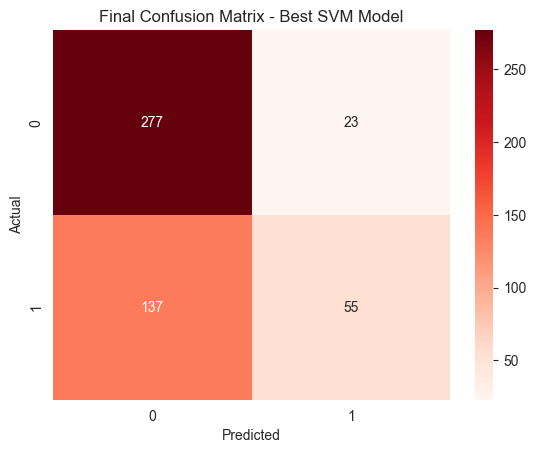

In [35]:
print("--- Final Evaluation and Conclusion for SVM Classifier ---")

if grid_original.best_score_ >= grid_lda.best_score_:
    print("Conclusion: The model with original features performed better or equal in cross-validation.")
    print("Proceeding with the final test using the best SVM model on original scaled features.")

    final_model = grid_original.best_estimator_

    final_predictions = final_model.predict(X_test_scaled)
    final_accuracy = accuracy_score(y_test, final_predictions)

else:
    print("Conclusion: The model with LDA-reduced features performed better in cross-validation.")
    print("Proceeding with the final test using the best SVM model on LDA features.")

    final_model = grid_lda.best_estimator_

    final_predictions = final_model.predict(X_test_lda)
    final_accuracy = accuracy_score(y_test, final_predictions)

# Ispisujemo finalne rezultate
print(f"\nFinal Model Details: {final_model}")
print(f"\nFinal Accuracy on the independent test set: {final_accuracy:.4f}")

print("\nFinal Classification Report on the test set:")
print(classification_report(y_test, final_predictions))

print("\nFinal Confusion Matrix on the test set:")
cm_final = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix - Best SVM Model')
plt.show()